# Integración del Dataset Unificado — R6 (7 Empresas BVL, universo vigente)

Construcción y validación del panel único `(ticker, date)` que combina mercado + indicadores técnicos (R3), sentimiento de noticias (R5) y fundamentales trimestrales (R4) sobre el calendario bursátil de la BVL — el espacio de observación final que verá el agente DRL.

Para la narrativa completa de las decisiones (qué se decidió, por qué, y los hallazgos relevantes para la tesis) ver `docs/hallazgos_integracion_R6.txt`. Este notebook es la evidencia visual/cuantitativa que sustenta ese documento.

| Ticker | Empresa | Sector |
|--------|---------|--------|
| CREDITC1 | Banco de Crédito del Perú | Banca |
| ALICORC1 | Alicorp | Alimentos |
| INRETC1 | InRetail Peru Corp | Retail / farmacias |
| CPACASC1 | Cementos Pacasmayo | Construcción |
| FERREYC1 | Ferreycorp | Bienes de capital |
| LUSURC1 | Luz del Sur | Electricidad |
| MINSURI1 | Minsur | Minería (estaño/cobre) |

Panel vigente: 7 activos x 3,512 fechas (2012-01-02 a 2025-12-30), con la corrección de fecha de la BVL del 2026-09-12 y el canal de sentimiento rediseñado (conteos categóricos y EWMAs; ver `docs/taxonomia_eventos_R5.txt`).

**Decisiones cubiertas en este notebook:**
1. Calendario bursátil construido en R6 (no en el entorno DRL, OE1).
2. Sentimiento: roll-forward de noticias en día no bursátil + reagregación (los CONTEOS se suman; solo el score se promedia).
3. Ancla sintética de `days_since_news` en el día 0 de cada activo.
4. Fundamentales propagados con `merge_asof` (sin look-ahead).
5. Días sin cotización (`is_no_trade`) y días con precio arrastrado (`is_stale`): precio sostenido + indicadores recalculados.
6. Corrección de `rsi_14` (bug de fórmula preexistente de R3, no imputación de datos faltantes).
7. Valoración fundamental: P/E y Dividend Yield diarios en el panel (capitalización / utilidad TTM, y dividendos TTM / precio).

## 1. Carga de datos

Se cargan tanto las fuentes intermedias (mercado y sentimiento por activo, fundamentales crudos) como el panel final ya construido, para poder comparar "antes/después" de cada decisión de R6 de forma reproducible en vez de solo narrar los números.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.integration.build_dataset import (
    build_trading_calendar, _align_sentiment_to_calendar, feature_views,
)
from src.fundamentals.fundamentals_client import compute_ratios
# Las rutas del cliente de R4 son relativas a la raíz del repo; el notebook corre
# desde notebooks/. Sin esto el conteo híbrido de acciones (Informe Bursátil
# Mensual de la BVL) no se encuentra y se cae al capital del balance.
import src.fundamentals.fundamentals_client as _fc
_fc._BVL_MENSUAL_CACHE = pathlib.Path('../data/interim/bvl_mensual.parquet')
from src.universe import Config

DATA_INTERIM = pathlib.Path('../data/interim')
DATA_RAW = pathlib.Path('../data/raw')
DATA_PROCESSED = pathlib.Path('../data/processed')

TICKERS = ['CREDITC1', 'ALICORC1', 'INRETC1', 'CPACASC1', 'FERREYC1', 'LUSURC1', 'MINSURI1']
NOMBRES = {
    'CREDITC1': 'BCP',
    'ALICORC1': 'Alicorp',
    'INRETC1':  'InRetail',
    'CPACASC1': 'Pacasmayo',
    'FERREYC1': 'Ferreycorp',
    'LUSURC1':  'Luz del Sur',
    'MINSURI1': 'Minsur',
}
COLORES = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
COLOR_MAP = dict(zip(TICKERS, COLORES))

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})

market = {t: pd.read_parquet(DATA_INTERIM / f'market_{t}.parquet') for t in TICKERS}
sentiment_raw = {t: pd.read_parquet(DATA_INTERIM / f'sentiment_{t}.parquet') for t in TICKERS}
ASSETS = {a.bvl: a for a in Config.load('../config.yaml').assets}
ratios = {t: compute_ratios(pd.read_parquet(DATA_RAW / f'fund_{t}_smv.parquet'), asset=ASSETS[t]) for t in TICKERS}
unified = pd.read_parquet(DATA_PROCESSED / 'dataset_unificado.parquet')

print(f"Panel unificado: {unified.shape[0]} filas x {unified.shape[1]} columnas")
print(f"Rango: {unified['date'].min().date()} -> {unified['date'].max().date()}")
print(f"Activos: {sorted(unified['ticker'].unique())}")

[shares] CREDITC1: 28/83 periodo(s) sin conteo oficial de la BVL -> capital del balance SMV.
[shares] ALICORC1: 28/84 periodo(s) sin conteo oficial de la BVL -> capital del balance SMV.
[shares] CPACASC1: 28/84 periodo(s) sin conteo oficial de la BVL -> capital del balance SMV.


[shares] FERREYC1: 28/84 periodo(s) sin conteo oficial de la BVL -> capital del balance SMV.
[shares] LUSURC1: 28/84 periodo(s) sin conteo oficial de la BVL -> capital del balance SMV.
Panel unificado: 24584 filas x 120 columnas
Rango: 2012-01-02 -> 2025-12-30
Activos: ['ALICORC1', 'CPACASC1', 'CREDITC1', 'FERREYC1', 'INRETC1', 'LUSURC1', 'MINSURI1']


## 2. Calendario bursátil: construido en R6, no en el entorno (OE1)

`build_trading_calendar()` toma la UNIÓN de fechas con cotización de cualquiera de los 7 activos (no el calendario de uno solo) — esa es la decisión de diseño: el panel define qué días existen como fila, el entorno DRL solo consume ese índice ya resuelto. Cada activo individual puede tener menos filas propias (iliquidez, ver sección 6); eso se refleja como `is_no_trade`, no como un calendario más corto.

In [2]:
cal = build_trading_calendar(pd.concat(market.values(), ignore_index=True))
print(f"Calendario bursátil unificado: {len(cal)} días "
      f"({cal.min().date()} -> {cal.max().date()})")

cal_df = pd.DataFrame([
    {'ticker': t, 'empresa': NOMBRES[t], 'filas_propias_R3': len(market[t]),
     'dias_calendario_unificado': len(cal),
     'huecos_no_trade': len(cal) - len(market[t])}
    for t in TICKERS
])
display(cal_df)

Calendario bursátil unificado: 3512 días (2012-01-02 -> 2025-12-30)


,ticker,empresa,filas_propias_R3,dias_calendario_unificado,huecos_no_trade
0,CREDITC1,BCP,3510,3512,2
1,ALICORC1,Alicorp,3512,3512,0
2,INRETC1,InRetail,3320,3512,192
3,CPACASC1,Pacasmayo,3512,3512,0
4,FERREYC1,Ferreycorp,3512,3512,0
5,LUSURC1,Luz del Sur,3512,3512,0
6,MINSURI1,Minsur,3512,3512,0


## 3. Sentimiento: roll-forward de noticias + reagregación (sin decaimiento)

Las noticias publicadas en día NO bursátil (fin de semana, feriado BVL) se asignan al SIGUIENTE día hábil antes de construir el panel — evita look-ahead (una noticia del sábado no pudo afectar el cierre del viernes) y recupera cobertura que antes se perdía fuera del calendario. Si ese día hábil ya tenía noticia propia, se reagregan con media ponderada por `n_articles` (consistente con `daily_aggregation: mean` de R5) y las columnas de CONTEO por categoría se SUMAN. Sobre esos conteos se construyen las EWMAs del canal (`sent_{pos,neu,neg}_ewma_{5,20,60}`); se conservan además las columnas de contexto `days_since_news`, `has_news`, `n_articles`.

In [3]:
rows = []
for t in TICKERS:
    raw = sentiment_raw[t].copy()
    raw['date'] = pd.to_datetime(raw['date'])
    en_calendario = raw['date'].isin(cal).sum()
    tras_roll = int(unified.loc[unified['ticker'] == t, 'has_news'].sum())
    rows.append({
        'ticker': t, 'noticias_dias_R5': len(raw),
        'dias_ya_en_calendario': en_calendario,
        'dias_tras_roll_forward': tras_roll,
        '%_cobertura_antes': round(en_calendario / len(cal) * 100, 1),
        '%_cobertura_despues': round(tras_roll / len(cal) * 100, 1),
    })
cov_df = pd.DataFrame(rows)
display(cov_df)
print(f"\nGanancia neta de cobertura por roll-forward: "
      f"{(cov_df['dias_tras_roll_forward'] - cov_df['dias_ya_en_calendario']).sum()} "
      f"días-activo recuperados de fin de semana/feriado.")

,ticker,noticias_dias_R5,dias_ya_en_calendario,dias_tras_roll_forward,%_cobertura_antes,%_cobertura_despues
0,CREDITC1,3013,2228,2311,63.4,65.8
1,ALICORC1,1195,990,1080,28.2,30.8
2,INRETC1,1843,1369,1543,39.0,43.9
3,CPACASC1,673,581,640,16.5,18.2
4,FERREYC1,1207,976,1091,27.8,31.1
5,LUSURC1,747,580,681,16.5,19.4
6,MINSURI1,724,615,687,17.5,19.6



Ganancia neta de cobertura por roll-forward: 694 días-activo recuperados de fin de semana/feriado.


**Ejemplo real de colisión y reagregación** — se busca en CREDITC1 la primera fecha de fin de semana con noticias cuyo lunes siguiente también tenía noticias propias: en el panel, los conteos del lunes son la SUMA de ambos días.

In [4]:
ej = sentiment_raw['CREDITC1'].copy()
ej['date'] = pd.to_datetime(ej['date'])
fechas = set(ej['date'])
finde = ej[~ej['date'].isin(cal)]
for d in finde['date']:
    destino = cal[cal.searchsorted(d)]
    if destino in fechas and destino.year >= 2013:
        break
cols = ['date', 'n_articles', 'n_relevantes', 'sentiment_score']
print(f'Crudo (R5): {d.date()} (no bursátil) y {destino.date()} (día hábil siguiente)')
display(ej[ej['date'].isin([d, destino])][cols])
print('Panel R6 tras el roll-forward (los conteos se suman):')
display(unified.loc[(unified['ticker'] == 'CREDITC1') & (unified['date'] == destino),
                    ['date', 'has_news', 'n_articles', 'n_relevantes']])

Crudo (R5): 2013-06-30 (no bursátil) y 2013-07-01 (día hábil siguiente)


,date,n_articles,n_relevantes,sentiment_score
16,2013-06-30,1,0,0.0
17,2013-07-01,1,0,0.0


Panel R6 tras el roll-forward (los conteos se suman):


,date,has_news,n_articles,n_relevantes
7400,2013-07-01,1,2,0.0


**`days_since_news`** crece sin tope mientras no hay noticia nueva; la cola es muy pesada (de cientos de días para los activos con menos cobertura mediática). Por eso se decidió que el panel guarde el valor CRUDO y que la transformación `log1p` (no `log` puro, porque `days_since_news=0` en días con noticia) se aplique en OE1 al construir la observación del agente, no aquí — mismo principio de separación que el calendario: R6 guarda crudo, OE1 transforma.

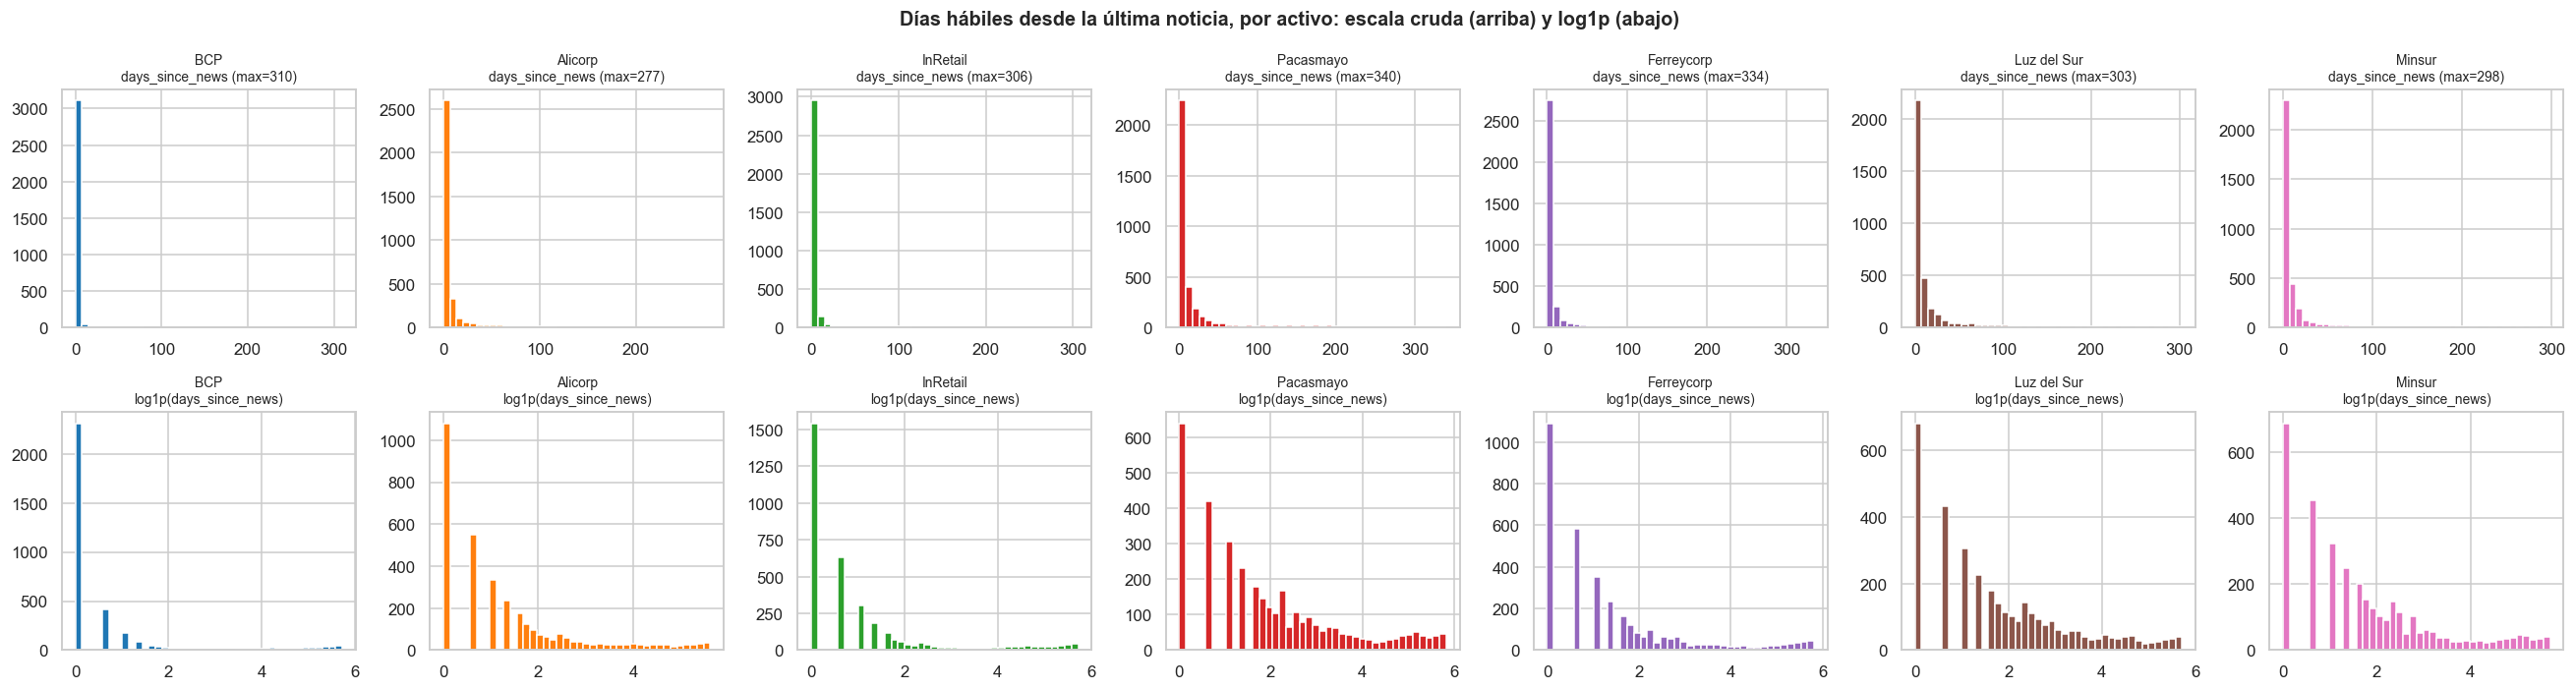

In [5]:
fig, axes = plt.subplots(2, 7, figsize=(24, 6.5))
fig.suptitle('Días hábiles desde la última noticia, por activo: escala cruda (arriba) y log1p (abajo)',
             fontsize=13, fontweight='bold')
for ax, t in zip(axes[0], TICKERS):
    vals = unified.loc[unified['ticker'] == t, 'days_since_news']
    ax.hist(vals, bins=40, color=COLOR_MAP[t])
    ax.set_title(f'{NOMBRES[t]}\ndays_since_news (max={vals.max()})', fontsize=9)
for ax, t in zip(axes[1], TICKERS):
    vals = unified.loc[unified['ticker'] == t, 'days_since_news']
    ax.hist(np.log1p(vals), bins=40, color=COLOR_MAP[t])
    ax.set_title(f'{NOMBRES[t]}\nlog1p(days_since_news)', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Ancla sintética en el día 0 (sin NaN antes de la primera noticia)

Antes de la primera noticia histórica real de un activo, en vez de NaN se trata el día 0 del panel como si hubiera un evento neutral (`sentiment_score_last=0`, `days_since_news=0`) — evita inventar un segundo valor sentinela arbitrario y deja que `days_since_news` crezca de forma normal desde el inicio del panel.

In [6]:
primeras_filas = (unified.sort_values('date')
                  .groupby('ticker').first()
                  [['date', 'has_news', 'sentiment_score_last', 'days_since_news']])
display(primeras_filas)
print('NaN en days_since_news (todo el panel):', unified['days_since_news'].isna().sum())
print('NaN en sentiment_score_last (todo el panel):', unified['sentiment_score_last'].isna().sum())

,date,has_news,sentiment_score_last,days_since_news
ticker,,,,
ALICORC1,2012-01-02,0,0.0,0
CPACASC1,2012-01-02,0,0.0,0
CREDITC1,2012-01-02,0,0.0,0
FERREYC1,2012-01-02,1,0.0,0
INRETC1,2012-01-02,0,0.0,0
LUSURC1,2012-01-02,0,0.0,0
MINSURI1,2012-01-02,0,0.0,0


NaN en days_since_news (todo el panel): 0
NaN en sentiment_score_last (todo el panel): 0


## 5. Fundamentales: propagación con `merge_asof` (sin look-ahead)

`pd.merge_asof(..., direction='backward')` sobre `known_date` asigna a cada día de mercado el ÚLTIMO trimestre que ya era público en esa fecha — nunca un trimestre futuro. `known_date` es la fecha REAL del hecho de importancia en la BVL cuando existe, y si no un lag de respaldo calibrado por activo (D20). InRetail tiene fundamentales desde su salida a bolsa (2012); el resto, desde 2005.

NaN en ratios fundamentales (todo el panel):
roe            223
roa            223
net_margin     270
debt_equity    223
debt_ratio     223
dtype: int64


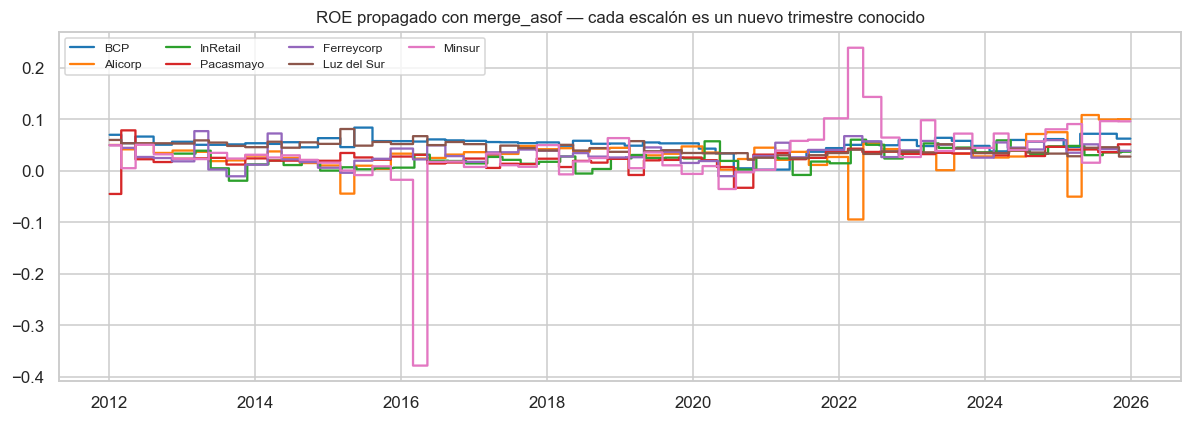

In [7]:
nan_fund = unified[['roe', 'roa', 'net_margin', 'debt_equity', 'debt_ratio']].isna().sum()
print('NaN en ratios fundamentales (todo el panel):')
print(nan_fund)

fig, ax = plt.subplots(figsize=(11, 4))
for t in TICKERS:
    sub = unified[unified['ticker'] == t]
    ax.step(sub['date'], sub['roe'], where='post', label=NOMBRES[t], color=COLOR_MAP[t])
ax.set_title('ROE propagado con merge_asof — cada escalón es un nuevo trimestre conocido')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

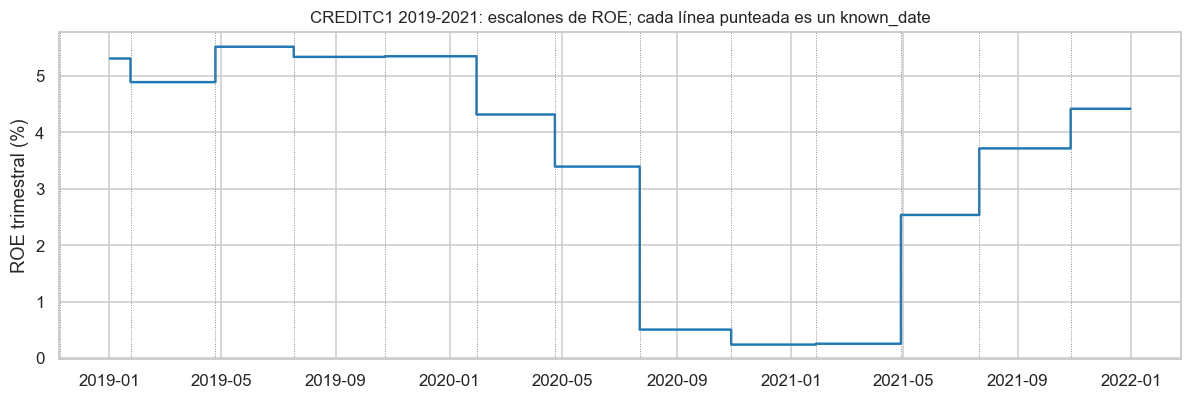

In [8]:
sub = unified[(unified['ticker'] == 'CREDITC1') &
              (unified['date'] >= '2019-01-01') & (unified['date'] <= '2021-12-31')]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.step(sub['date'], sub['roe'] * 100, where='post', color=COLOR_MAP['CREDITC1'], lw=1.6)
for kd in sub['known_date'].dropna().unique():
    ax.axvline(pd.Timestamp(kd), color='grey', lw=0.6, ls=':')
ax.set_ylabel('ROE trimestral (%)')
ax.set_title('CREDITC1 2019-2021: escalones de ROE; cada línea punteada es un known_date')
plt.tight_layout()
plt.show()

## 5b. Valoración fundamental: P/E y Dividend Yield

P/E y DY son las únicas señales fundamentales que NO se propagan tal cual desde R4: se calculan a nivel DIARIO en el panel porque combinan el precio diario (R3) con insumos trimestrales (R4) y los dividendos (R3).

- **P/E** = `close_raw × acciones_en_circulación / UtilidadNeta_TTM` = capitalización / utilidad TTM. Se usa `close_raw` (no `close_split_adj`): es invariante a splits y evita mezclar bases de acciones. Es NaN cuando la utilidad TTM ≤ 0 (años de pérdida) — ausencia SEMÁNTICA, no hueco de datos.
- **DY** = dividendos por acción TTM (PEN) / `close_raw`.

Las acciones en circulación se reconstruyen de la SMV (`(Capital Emitido − tesorería) / nominal`), con el `quantity` de la BVL y el conteo HÍBRIDO vigente (emitidas según el Informe Bursátil Mensual de la BVL menos la tesorería de la SMV; InRetail por tramos; Minsur con el total económico). Metodología y validación completas: `docs/pipeline_extraccion_datos.txt` §3.10.2 y `docs/hallazgos_fundamentales_R4.txt` §5.9.

Cobertura de P/E (NaN = años de pérdida) y DY en el panel:


,ticker,empresa,pe_no_nan_%,pe_mediana,dy_no_nan_%,dy_mediana_%
0,CREDITC1,BCP,92.9,13.0,100.0,3.59
1,ALICORC1,Alicorp,93.2,20.2,100.0,2.16
2,INRETC1,InRetail,86.5,26.6,94.5,0.94
3,CPACASC1,Pacasmayo,100.0,15.9,100.0,4.91
4,FERREYC1,Ferreycorp,100.0,8.3,100.0,5.76
5,LUSURC1,Luz del Sur,100.0,12.7,100.0,5.42
6,MINSURI1,Minsur,83.2,8.8,100.0,4.80


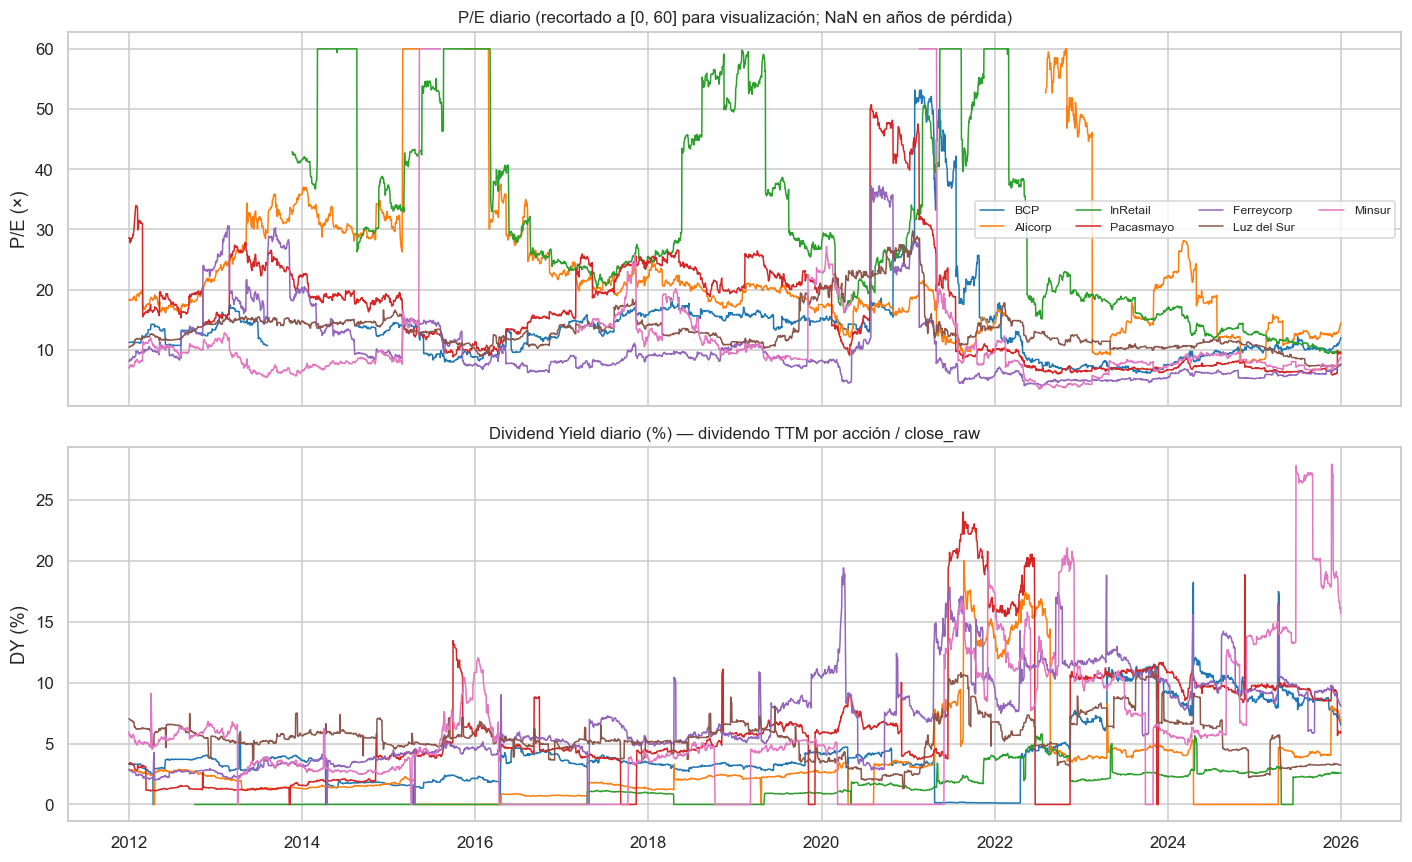

In [9]:
cov = []
for t in TICKERS:
    g = unified[unified['ticker'] == t]
    cov.append({'ticker': t, 'empresa': NOMBRES[t],
                'pe_no_nan_%': round(g['pe'].notna().mean() * 100, 1),
                'pe_mediana': round(g['pe'].median(), 1),
                'dy_no_nan_%': round(g['dy'].notna().mean() * 100, 1),
                'dy_mediana_%': round(g['dy'].median() * 100, 2)})
print('Cobertura de P/E (NaN = años de pérdida) y DY en el panel:')
display(pd.DataFrame(cov))

fig, (axpe, axdy) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for t in TICKERS:
    g = unified[unified['ticker'] == t].sort_values('date')
    axpe.plot(g['date'], g['pe'].clip(lower=0, upper=60),
              color=COLOR_MAP[t], lw=1.0, label=NOMBRES[t])
    axdy.plot(g['date'], g['dy'] * 100, color=COLOR_MAP[t], lw=1.0, label=NOMBRES[t])
axpe.set_title('P/E diario (recortado a [0, 60] para visualización; NaN en años de pérdida)')
axpe.set_ylabel('P/E (×)'); axpe.legend(ncol=4, fontsize=8)
axdy.set_title('Dividend Yield diario (%) — dividendo TTM por acción / close_raw')
axdy.set_ylabel('DY (%)')
plt.tight_layout(); plt.show()

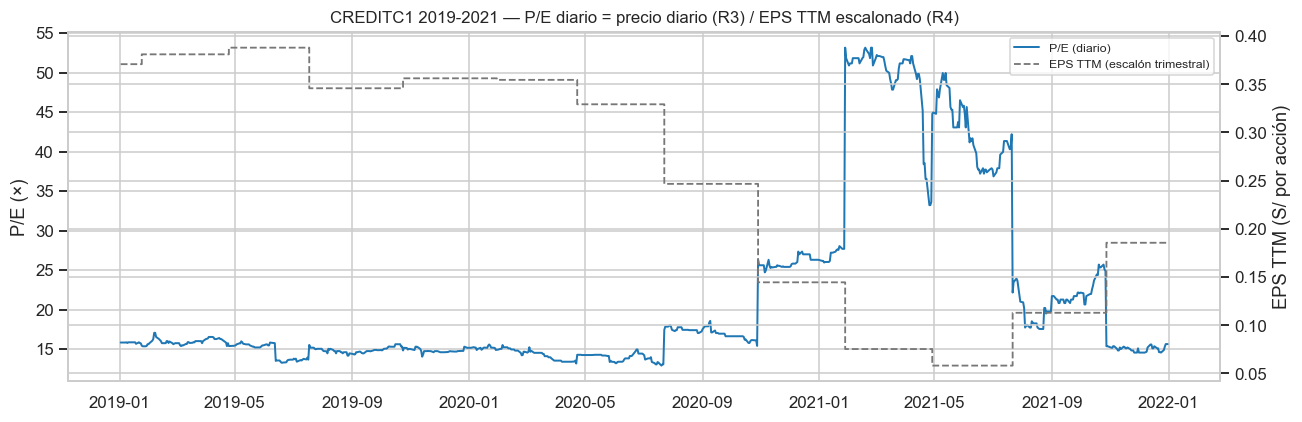

In [10]:
# P/E integra precio DIARIO (R3) con EPS TRIMESTRAL (R4): se mueve a diario
# dentro del trimestre y salta cuando entra un nuevo known_date (merge_asof).
sub = unified[(unified['ticker'] == 'CREDITC1') &
              (unified['date'] >= '2019-01-01') & (unified['date'] <= '2021-12-31')].sort_values('date')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sub['date'], sub['pe'], color=COLOR_MAP['CREDITC1'], lw=1.3, label='P/E (diario)')
ax2 = ax.twinx()
ax2.step(sub['date'], sub['eps_ttm'], where='post', color='#777', lw=1.2, ls='--',
         label='EPS TTM (escalón trimestral)')
ax.set_title('CREDITC1 2019-2021 — P/E diario = precio diario (R3) / EPS TTM escalonado (R4)')
ax.set_ylabel('P/E (×)'); ax2.set_ylabel('EPS TTM (S/ por acción)')
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, fontsize=8, loc='best')
plt.tight_layout(); plt.show()

## 6. Días sin cotización y precio arrastrado (`is_no_trade`, `is_stale`)

Dos fenómenos distintos: `is_no_trade` = el activo no tiene fila propia ese día (en el universo vigente casi solo InRetail antes de su salida a bolsa); `is_stale` = la BVL publica un cierre IDÉNTICO al del día anterior (precio de referencia arrastrado, sin cambio). El segundo es la iliquidez dominante: 3% a 44% de los días según el activo. En ambos casos se arrastra el último `close_total_return` conocido y se RECALCULAN los indicadores técnicos sobre la serie ya completa (`technical_indicators.add_indicators`) en vez de arrastrar a ciegas los valores de los indicadores — así `ret_1d=0` y `volatility_20` decaen correctamente durante el tramo sin operación. No se completa open/high/low/volumen: esa ruta ya se descartó explícitamente (ver `docs/justificacion_cierre_vs_ohlcv.txt` — el agente solo usa `close_total_return`).

In [11]:
def episodios(mask):
    grp = (mask != mask.shift()).cumsum()
    return mask[mask].groupby(grp[mask]).size()

rows = []
for t in TICKERS:
    sub = unified[unified['ticker'] == t].sort_values('date').reset_index(drop=True)
    nt = episodios(sub['is_no_trade'].astype(bool))
    st = episodios(sub['is_stale'].astype(bool))
    rows.append({
        'ticker': t, 'dias_no_trade': int(sub['is_no_trade'].sum()),
        'racha_max_no_trade': int(nt.max()) if len(nt) else 0,
        'dias_stale_%': round(sub['is_stale'].mean() * 100, 1),
        'rachas_stale': len(st), 'racha_max_stale': int(st.max()) if len(st) else 0,
    })
display(pd.DataFrame(rows))

,ticker,dias_no_trade,racha_max_no_trade,dias_stale_%,rachas_stale,racha_max_stale
0,CREDITC1,2,2,41.4,758,14
1,ALICORC1,0,0,24.0,581,6
2,INRETC1,192,192,3.0,98,3
3,CPACASC1,0,0,27.9,648,9
4,FERREYC1,0,0,26.5,616,10
5,LUSURC1,0,0,43.5,737,31
6,MINSURI1,0,0,35.1,698,11


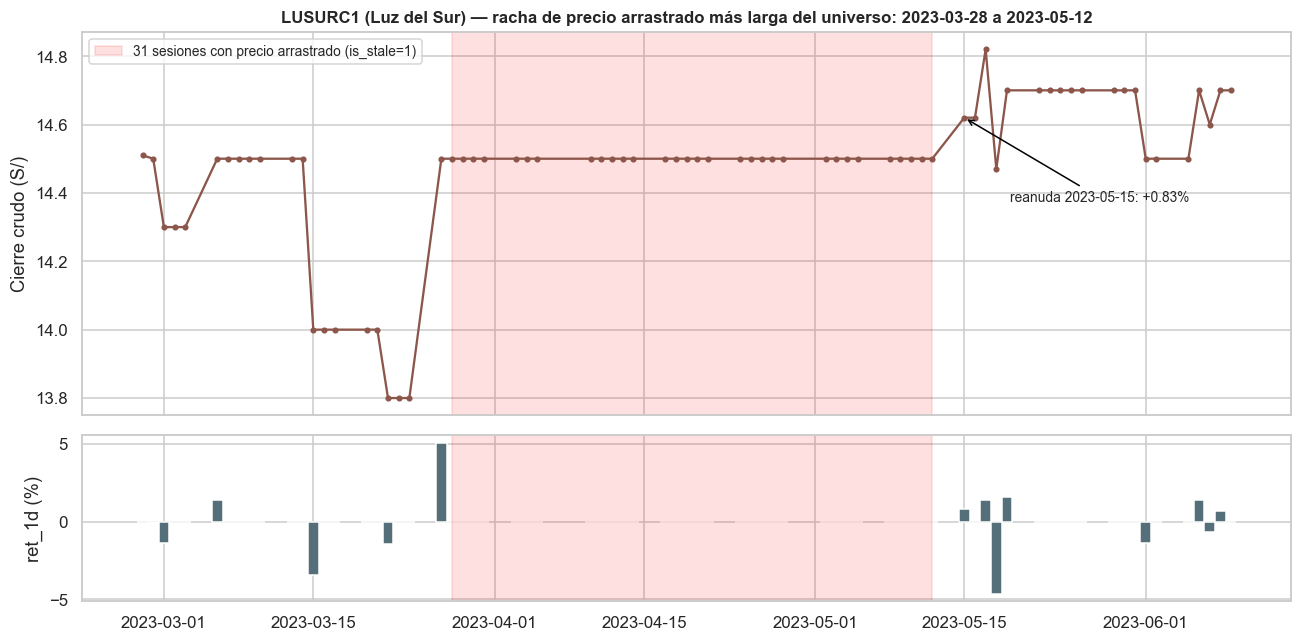

In [12]:
# La racha de precio arrastrado más larga del universo vigente (calculada, no fijada)
mejor = None
for t in TICKERS:
    g = unified[unified['ticker'] == t].sort_values('date').reset_index(drop=True)
    m = g['is_stale'].astype(bool)
    grp = (m != m.shift()).cumsum()
    for _, bloque in g[m].groupby(grp[m]):
        if mejor is None or len(bloque) > mejor[2]:
            mejor = (t, bloque['date'].iloc[0], len(bloque), bloque['date'].iloc[-1])
t_ej, ini, n_racha, fin = mejor
g = unified[unified['ticker'] == t_ej].sort_values('date').reset_index(drop=True)
i_fin = g.index[g['date'] == fin][0]
reanuda = g.loc[i_fin + 1]
win = g[(g['date'] >= ini - pd.Timedelta(days=30)) & (g['date'] <= fin + pd.Timedelta(days=30))]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1.3]})
ax.plot(win['date'], win['close_raw'], marker='o', ms=3, color=COLOR_MAP[t_ej])
ax.axvspan(ini, fin, color='red', alpha=0.12, label=f'{n_racha} sesiones con precio arrastrado (is_stale=1)')
ax.annotate(f'reanuda {reanuda["date"]:%Y-%m-%d}: {reanuda["ret_1d"]:+.2%}',
            xy=(reanuda['date'], reanuda['close_raw']), xytext=(30, -55),
            textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black', lw=1), fontsize=9)
ax.set_ylabel('Cierre crudo (S/)')
ax.legend(loc='upper left', fontsize=9)
ax.set_title(f'{t_ej} ({NOMBRES[t_ej]}) — racha de precio arrastrado más larga del universo: '
             f'{ini:%Y-%m-%d} a {fin:%Y-%m-%d}', fontweight='bold')
ax2.bar(win['date'], win['ret_1d'] * 100, width=1.0, color='#546E7A')
ax2.axvspan(ini, fin, color='red', alpha=0.12)
ax2.set_ylabel('ret_1d (%)')
plt.tight_layout()
plt.show()

## 7. Corrección de `rsi_14`: bug de fórmula preexistente, no imputación

Al validar quedó expuesto que `rsi_14` ya tenía **27.5% de NaN en los parquets originales de R3**, independiente de los días `is_no_trade` de esta sesión. Causa: la fórmula original hacía `loss.replace(0, np.nan)` — cuando una ventana de 14 días no tenía ninguna pérdida, el RSI quedaba indefinido en vez de calcularse. Esto NO es un hueco de datos (el precio, el delta diario, la ganancia y la pérdida de cada ventana son 100% reales y observados) — es un caso límite de la fórmula mal manejado. Se corrigió con dos reglas explícitas:
- pérdida=0, ganancia>0 → RSI=100 (límite exacto de la fórmula de Wilder, igual que TA-Lib/pandas-ta — sin ambigüedad).
- pérdida=0, ganancia=0 (ventana totalmente plana, 0/0 verdaderamente indefinido) → RSI=50 (convención "sin señal de momentum", no 100, porque ahí no hubo movimiento real — coherente con que esos tramos ya están marcados `is_no_trade`).

La celda siguiente reproduce la fórmula ANTERIOR (ya corregida en `src/market/technical_indicators.py`) solo para esta comparación.

In [13]:
def rsi_formula_anterior(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

rows = []
for t in TICKERS:
    m = market[t].sort_values('date')
    nan_antes = rsi_formula_anterior(m['close_total_return']).isna().sum()
    nan_despues = m['rsi_14'].isna().sum()
    rows.append({
        'ticker': t, 'filas': len(m),
        'NaN_formula_anterior': int(nan_antes), '%_anterior': round(nan_antes / len(m) * 100, 1),
        'NaN_formula_corregida': int(nan_despues), '%_corregida': round(nan_despues / len(m) * 100, 1),
    })
display(pd.DataFrame(rows))

,ticker,filas,NaN_formula_anterior,%_anterior,NaN_formula_corregida,%_corregida
0,CREDITC1,3510,83,2.4,14,0.4
1,ALICORC1,3512,23,0.7,14,0.4
2,INRETC1,3320,22,0.7,14,0.4
3,CPACASC1,3512,17,0.5,14,0.4
4,FERREYC1,3512,27,0.8,14,0.4
5,LUSURC1,3512,137,3.9,14,0.4
6,MINSURI1,3512,40,1.1,14,0.4


In [14]:
print('RSI == 100 (sin pérdidas, con ganancia):', int((unified['rsi_14'] == 100).sum()))
print('RSI == 50  (ventana totalmente plana)   :', int((unified['rsi_14'] == 50).sum()))

# En la misma racha de la sección 6 el RSI converge a 50 (ventana plana)
sub = g[(g['date'] >= fin - pd.Timedelta(days=7)) & (g['date'] <= reanuda['date'])]
display(sub[['date', 'close_total_return', 'is_stale', 'rsi_14']])

RSI == 100 (sin pérdidas, con ganancia): 233
RSI == 50  (ventana totalmente plana)   : 879


,date,close_total_return,is_stale,rsi_14
2849,2023-05-05,16.327779,1,50.0
2850,2023-05-08,16.327779,1,50.0
2851,2023-05-09,16.327779,1,50.0
2852,2023-05-10,16.327779,1,50.0
2853,2023-05-11,16.327779,1,50.0
2854,2023-05-12,16.327779,1,50.0
2855,2023-05-15,16.462906,0,100.0


## 8. Vistas de señales para los experimentos DRL (R8)

Las configuraciones de señales de R8 NO son datasets separados: son selecciones de columnas sobre este mismo panel único. (Las vistas que consume el agente se definen en `src/env/features.py`; esta función lista las de R6.)

In [15]:
views = feature_views(unified)
for name, cols in views.items():
    print(f"{name} ({len(cols)} columnas):")
    print(f"  {cols}\n")

solo_mercado (16 columnas):
  ['open', 'high', 'low', 'close', 'volume', 'is_no_trade', 'ret_1d', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'rsi_14', 'volatility_20', 'is_stale']

mercado_sentimiento (29 columnas):
  ['open', 'high', 'low', 'close', 'volume', 'is_no_trade', 'ret_1d', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'rsi_14', 'volatility_20', 'is_stale', 'sentiment_score_last', 'days_since_news', 'has_news', 'n_articles', 'sent_pos_ewma_5', 'sent_pos_ewma_20', 'sent_pos_ewma_60', 'sent_neu_ewma_5', 'sent_neu_ewma_20', 'sent_neu_ewma_60', 'sent_neg_ewma_5', 'sent_neg_ewma_20', 'sent_neg_ewma_60']

mercado_sentimiento_tramos (38 columnas):
  ['open', 'high', 'low', 'close', 'volume', 'is_no_trade', 'ret_1d', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'rsi_14', 'volatility_20', 'is_stale', 'sentiment_score_last', 'days_since_news', 'has_news', 'n_articles', 'sent_alto_pos_ewma_5', 'sent_alto_pos_ewma_20', 'sent_alto_po

## 9. Síntesis final

In [16]:
print('=' * 64)
print('SÍNTESIS R6 — DATASET UNIFICADO')
print('=' * 64)
print(f"Panel: {unified.shape[0]} filas x {unified.shape[1]} columnas")
print(f"Activos: {unified['ticker'].nunique()} | "
      f"Calendario: {len(cal)} días ({cal.min().date()} -> {cal.max().date()})")
cov = unified.groupby('ticker')['has_news'].mean() * 100
print(f"Días con algún artículo tras roll-forward: {cov.min():.1f}% ({cov.idxmin()}) "
      f"a {cov.max():.1f}% ({cov.idxmax()}), promedio {cov.mean():.1f}%")
print(f"Días is_no_trade: {int(unified['is_no_trade'].sum())} "
      f"({unified['is_no_trade'].mean() * 100:.2f}% del panel)")
print('NaN en columnas clave: ' + ', '.join(
    f"{c}={unified[c].isna().sum()}"
    for c in ['sent_pos_ewma_20', 'sent_neg_ewma_20', 'days_since_news', 'has_news', 'n_articles',
              'roe', 'roa', 'rsi_14', 'close_total_return']
))

SÍNTESIS R6 — DATASET UNIFICADO
Panel: 24584 filas x 120 columnas
Activos: 7 | Calendario: 3512 días (2012-01-02 -> 2025-12-30)
Días con algún artículo tras roll-forward: 18.2% (CPACASC1) a 65.8% (CREDITC1), promedio 32.7%
Días is_no_trade: 194 (0.79% del panel)
NaN en columnas clave: sent_pos_ewma_20=0, sent_neg_ewma_20=0, days_since_news=0, has_news=0, n_articles=0, roe=223, roa=223, rsi_14=290, close_total_return=192
